### PRECIFICAÇÃO INTELIGENTE NO VAREJO DIGITAL: MAXIMIZAÇÃO DE LUCRO POR MEIO DO MÉTODO DE NEWTON
Alvaro Koene Henning;
Bruno Nava Mainardi;
Fernando Henrique Lopes Fabian;
Kaique Vinicius Geska;
Rafael Borges da Silva;
Rafaela Eduarda de Oliveira Barreiros;
Prof. Dra. Rosangela Carline Schemmer.


In [1]:
# ETAPA 1 — Importações e leitura dos arquivos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("-" * 50)
print("ETAPA 1: Carregando dados...")
# Lendo os datasets (garanta que estejam na mesma pasta do script)
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')

print(f"Items carregados: {df_items.shape[0]} linhas.")
print(f"Produtos carregados: {df_products.shape[0]} linhas.\n")

--------------------------------------------------
ETAPA 1: Carregando dados...
Items carregados: 112650 linhas.
Produtos carregados: 32951 linhas.



In [2]:
# ETAPA 2 — Filtragem e merge
print("ETAPA 2: Filtrando SKU e cruzando dados...")
sku_alvo = 'aca2eb7d00ea1a7b8ebd4e68314663af'

# Filtrar apenas o produto alvo
df_sku = df_items[df_items['product_id'] == sku_alvo].copy()

# Merge com o dataset de produtos para trazer a categoria
df_sku_completo = df_sku.merge(df_products[['product_id', 'product_category_name']], on='product_id', how='left')

categoria = df_sku_completo['product_category_name'].iloc[0]
print(f"SKU isolado: {sku_alvo}")
print(f"Categoria confirmada: {categoria}\n")

ETAPA 2: Filtrando SKU e cruzando dados...
SKU isolado: aca2eb7d00ea1a7b8ebd4e68314663af
Categoria confirmada: moveis_decoracao



In [ ]:
# ETAPA 3 — Construção do dataset final
print("ETAPA 3: Construindo dataset diário...")
# Converter data de limite de envio para pegar apenas o dia (aproximação da data de venda)
df_sku_completo['Data'] = pd.to_datetime(df_sku_completo['shipping_limit_date']).dt.date

# Agrupar por dia: Média do preço e contagem de itens vendidos
df_final = df_sku_completo.groupby('Data').agg(
    Preço_unitário=('price', 'mean'),
    Quantidade_vendida=('order_item_id', 'count')
).reset_index()

# Criar as colunas solicitadas
df_final.rename(columns={'Preço_unitário': 'Preço unitário', 'Quantidade_vendida': 'Quantidade vendida'}, inplace=True)
df_final.insert(0, 'ID', sku_alvo)
df_final['Valor total vendido'] = df_final['Preço unitário'] * df_final['Quantidade vendida']
df_final['Custo do produto'] = 42.82 # 60% do preço médio estimado, média de mercado para o segmento de móveis de decoração

# Ordenar por data e salvar
df_final = df_final.sort_values('Data')
df_final.to_csv('dataset_sku_olist_final.csv', index=False)
print("Dataset 'dataset_sku_olist_final.csv' criado e salvo!\n")

ETAPA 3: Construindo dataset diário...
Dataset 'dataset_sku_olist_final.csv' criado e salvo!



ETAPA 4: Gerando gráficos de Análise Exploratória (EDA)...
Resumo Estatístico:
       Preço unitário  Quantidade vendida
count      135.000000          135.000000
mean        72.482963            3.903704
std          6.023394            3.468137
min         69.900000            1.000000
25%         69.900000            1.500000
50%         69.900000            3.000000
75%         75.000000            5.000000
max        109.900000           24.000000 



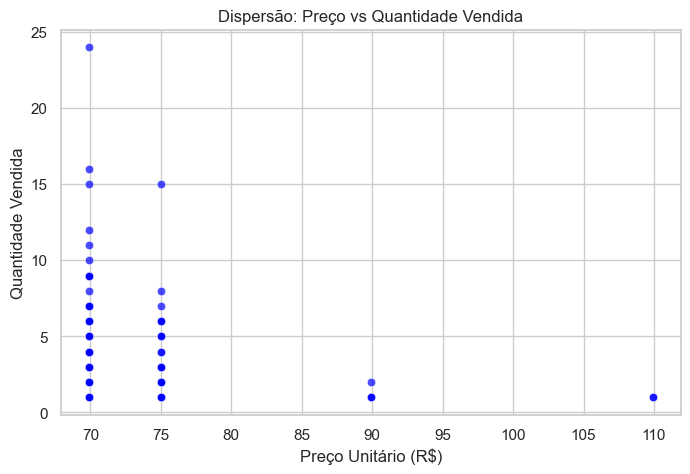

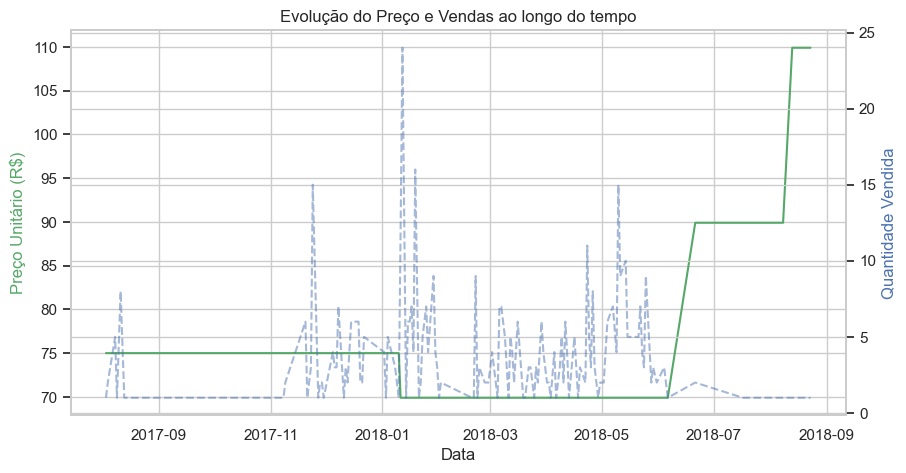

In [4]:
# ETAPA 4 — Análise exploratória
print("ETAPA 4: Gerando gráficos de Análise Exploratória (EDA)...")

# Estatísticas descritivas
print("Resumo Estatístico:")
print(df_final[['Preço unitário', 'Quantidade vendida']].describe(), "\n")

sns.set_theme(style="whitegrid")

# Gráfico 1: Dispersão (Preço x Demanda)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_final, x='Preço unitário', y='Quantidade vendida', color='blue', alpha=0.7)
plt.title('Dispersão: Preço vs Quantidade Vendida')
plt.xlabel('Preço Unitário (R$)')
plt.ylabel('Quantidade Vendida')
plt.show()

# Gráfico 2: Evolução no Tempo (Preço e Quantidade)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(df_final['Data'], df_final['Preço unitário'], 'g-', label='Preço')
ax2.plot(df_final['Data'], df_final['Quantidade vendida'], 'b--', alpha=0.5, label='Quantidade')
ax1.set_xlabel('Data')
ax1.set_ylabel('Preço Unitário (R$)', color='g')
ax2.set_ylabel('Quantidade Vendida', color='b')
plt.title('Evolução do Preço e Vendas ao longo do tempo')
plt.show()

In [5]:
# ETAPA 5 — Modelagem de demanda
print("ETAPA 5: Estimando Parâmetros da Demanda Linear...")
# Usamos polyfit (grau 1) para traçar a reta: y = mx + c -> Quantidade = -b*Preço + a
coeficientes = np.polyfit(df_final['Preço unitário'], df_final['Quantidade vendida'], 1)

# A inclinação da reta (m) será o nosso -b, e o intercepto será o a.
b = -coeficientes[0] 
a = coeficientes[1]  

print(f"Raciocínio: A regressão linear cruza preço e quantidade para achar a sensibilidade.")
print(f"Equação de Demanda: D(P) = {a:.2f} - {b:.2f} * P\n")

ETAPA 5: Estimando Parâmetros da Demanda Linear...
Raciocínio: A regressão linear cruza preço e quantidade para achar a sensibilidade.
Equação de Demanda: D(P) = 12.69 - 0.12 * P



ETAPA 6: Aplicando o Método de Newton-Raphson para Otimização...
Iter  | Preço Atual     | 1ª Derivada     | Erro           
-------------------------------------------------------
1     | R$ 80.00        | -1.52           | 6.25463
2     | R$ 73.75        | 0.00            | 0.00000

Convergência alcançada!

ETAPA 7: Gerando gráficos da Otimização...


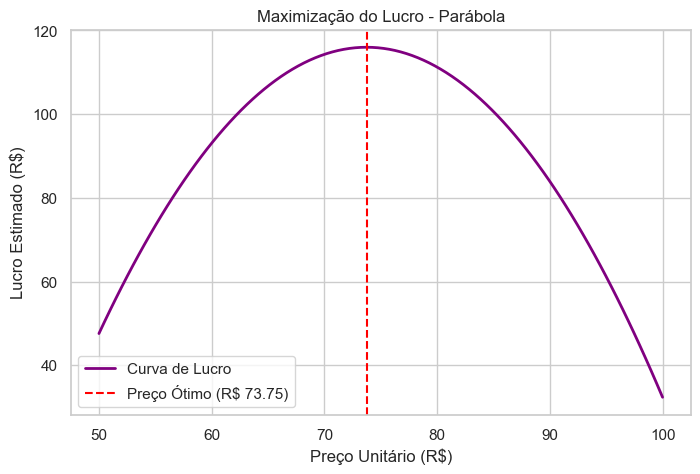

In [6]:
# ETAPA 6 — Método de Newton-Raphson
print("ETAPA 6: Aplicando o Método de Newton-Raphson para Otimização...")
# Função Lucro: L(P) = (P - C) * (a - b*P)
# Derivada Primeira L'(P) = a - 2*b*P + b*C  (Inclinação da curva)
# Derivada Segunda L''(P) = -2*b             (Aceleração, concavidade)

Custo_Fixo = 42.82
tolerancia = 1e-4

def newton_raphson_lucro(preco_inicial, a, b, C, max_iter=20):
    p_atual = preco_inicial
    historico = []
    
    print(f"{'Iter':<5} | {'Preço Atual':<15} | {'1ª Derivada':<15} | {'Erro':<15}")
    print("-" * 55)
    
    for i in range(1, max_iter + 1):
        # Cálculos matemáticos
        derivada_1 = a - 2 * b * p_atual + b * C
        derivada_2 = -2 * b
        
        # Fórmula de atualização do Newton-Raphson
        p_novo = p_atual - (derivada_1 / derivada_2)
        erro = abs(p_novo - p_atual)
        
        historico.append({'iteracao': i, 'preco': p_atual, 'erro': erro})
        
        print(f"{i:<5} | R$ {p_atual:<12.2f} | {derivada_1:<15.2f} | {erro:.5f}")
        
        if erro < tolerancia:
            break
            
        p_atual = p_novo
        
    return p_novo, historico

# Executando (Chute inicial: R$ 80,00)
preco_otimo, iteracoes = newton_raphson_lucro(80.0, a, b, Custo_Fixo)
print("\nConvergência alcançada!\n")

# ETAPA 7 — Gráficos da otimização
print("ETAPA 7: Gerando gráficos da Otimização...")

# Eixo X para o gráfico de lucro (preços variando de R$ 50 a R$ 100)
precos_simulados = np.linspace(50, 100, 100)
lucros_simulados = (precos_simulados - Custo_Fixo) * (a - b * precos_simulados)

plt.figure(figsize=(8, 5))
plt.plot(precos_simulados, lucros_simulados, color='purple', linewidth=2, label='Curva de Lucro')
plt.axvline(x=preco_otimo, color='red', linestyle='--', label=f'Preço Ótimo (R$ {preco_otimo:.2f})')
plt.title('Maximização do Lucro - Parábola')
plt.xlabel('Preço Unitário (R$)')
plt.ylabel('Lucro Estimado (R$)')
plt.legend()
plt.show()

In [7]:
# ETAPA 8 — Saídas finais
print("ETAPA 8: Resultados Finais!")
print("=" * 50)
demanda_otima = a - b * preco_otimo
lucro_maximo = (preco_otimo - Custo_Fixo) * demanda_otima

print(f"💰 Preço Ótimo Encontrado: R$ {preco_otimo:.2f}")
print(f"📦 Demanda Projetada: {demanda_otima:.2f} unidades/dia")
print(f"💵 Lucro Máximo Projetado: R$ {lucro_maximo:.2f}/dia")
print("=" * 50)

ETAPA 8: Resultados Finais!
💰 Preço Ótimo Encontrado: R$ 73.75
📦 Demanda Projetada: 3.75 unidades/dia
💵 Lucro Máximo Projetado: R$ 115.99/dia
